In [11]:
import pandas as pd
import matplotlib.pyplot as plt
data= {
    'City':['Kathmandu','Dharan','Biratnagar'],
    'Population':[150000,200000,500000]
}
df= pd.DataFrame(data)
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   City        3 non-null      object
 1   Population  3 non-null      int64 
dtypes: int64(1), object(1)
memory usage: 180.0+ bytes
None


<Axes: xlabel='City'>

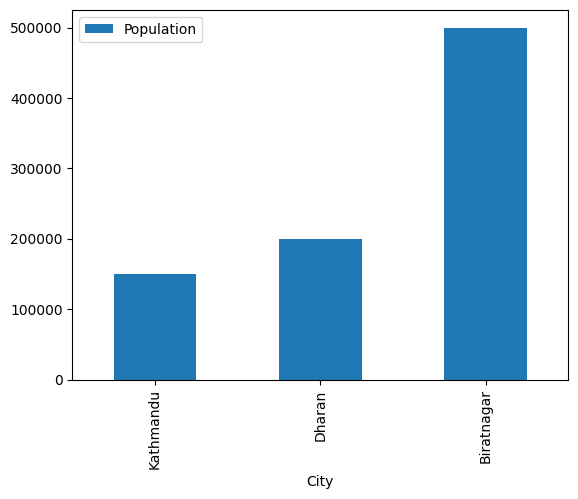

In [12]:

df.plot.bar(x='City',y='Population')


<Axes: xlabel='City'>

<Figure size 600x400 with 0 Axes>

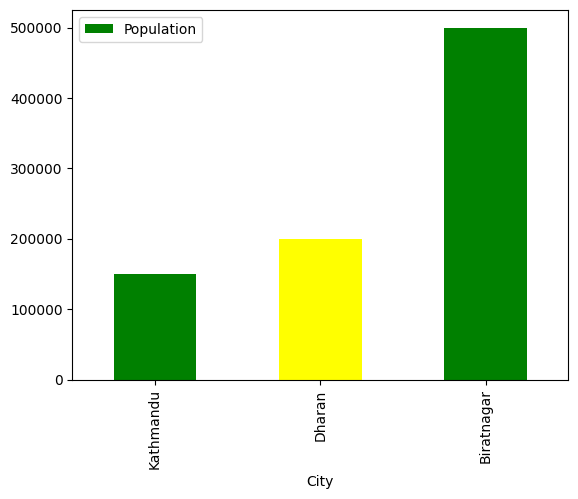

In [13]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
df.plot.bar(x='City',y='Population',color=['green','yellow'])

<Axes: ylabel='Population'>

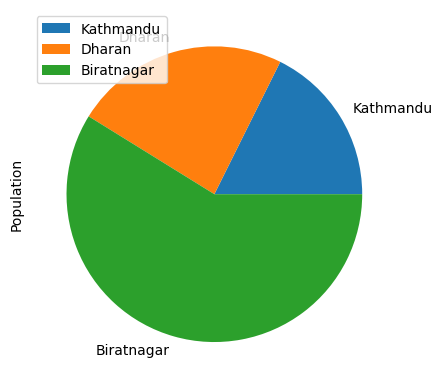

In [14]:
df.plot.pie(y='Population',labels=df['City'])

Merging in pandas

In [15]:
df_student=pd.DataFrame(
    {
        'student_id':[1,2,3],
        'name':['ram','hari','radha']
    }
)
df_marks= pd.DataFrame(
    {
        'student_id':[1,2,4],
        'marks':[100,50,88]
    }
)
print(df_student)
print(df_marks)

   student_id   name
0           1    ram
1           2   hari
2           3  radha
   student_id  marks
0           1    100
1           2     50
2           4     88


In [16]:
merged_inner= pd.merge(df_student, df_marks,on='student_id',how='inner')
print(merged_inner)

   student_id  name  marks
0           1   ram    100
1           2  hari     50


join


In [17]:
df_A= pd.DataFrame(
    {
        'temperature':[20,22,24]
    },
    index=['day1','day2','day3']
)

df_B= pd.DataFrame(
    {
        'Humidity':[60,65,75]
    },
    index=['day1','day2','day4']
)
print(df_A)

      temperature
day1           20
day2           22
day3           24


In [18]:
df_A.join(df_B, how='inner')


,temperature,Humidity
day1,20,60
day2,22,65


In [19]:
df_A.join(df_B, how='left')

,temperature,Humidity
day1,20,60.0
day2,22,65.0
day3,24,NaN


In [20]:
df_A.join(df_B, how='right')

,temperature,Humidity
day1,20.0,60
day2,22.0,65
day4,NaN,75


In [21]:
df_A.join(df_B, how='cross')

,temperature,Humidity
0,20,60
1,20,65
2,20,75
3,22,60
4,22,65
5,22,75
6,24,60
7,24,65
8,24,75


In [22]:
import pandas as pd
print(pd.__version__)


2.3.3


reshaping dataframes
Imp (wide vs long data foramt)

In [23]:
df_wide= pd.DataFrame({
    'name':["Ram","hari","comatozze"],
    'maths':[90,55,69],
    'science':[33,45,100]
})
print(df_wide)

        name  maths  science
0        Ram     90       33
1       hari     55       45
2  comatozze     69      100


In [24]:
df_long = pd.melt(
    df_wide,
    id_vars=['name'],
    var_name='subject',
    value_name='score'
)

print(df_long)


        name  subject  score
0        Ram    maths     90
1       hari    maths     55
2  comatozze    maths     69
3        Ram  science     33
4       hari  science     45
5  comatozze  science    100


In [25]:
df_long = pd.melt(
    df_wide,
    id_vars=['name'],
    var_name='subject',
    value_name='score'
)

print(df_long)


        name  subject  score
0        Ram    maths     90
1       hari    maths     55
2  comatozze    maths     69
3        Ram  science     33
4       hari  science     45
5  comatozze  science    100


In [26]:
df_original= df_long.pivot(
    index='name',
    columns='subject',
    values='score'

)
print(df_original)

subject    maths  science
name                     
Ram           90       33
comatozze     69      100
hari          55       45


In [27]:
df_stack= df_long.stack()
print(df_stack)

0  name             Ram
   subject        maths
   score             90
1  name            hari
   subject        maths
   score             55
2  name       comatozze
   subject        maths
   score             69
3  name             Ram
   subject      science
   score             33
4  name            hari
   subject      science
   score             45
5  name       comatozze
   subject      science
   score            100
dtype: object


In [28]:
df_unstacked= df_stack.unstack()

print(df_unstacked)

        name  subject score
0        Ram    maths    90
1       hari    maths    55
2  comatozze    maths    69
3        Ram  science    33
4       hari  science    45
5  comatozze  science   100


pivoting

In [29]:
df=pd.read_csv('data.csv'
)
print(df.info())
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Roll     5 non-null      int64  
 1   Name     4 non-null      object 
 2   Address  3 non-null      object 
 3   Age      4 non-null      float64
dtypes: float64(1), int64(1), object(2)
memory usage: 292.0+ bytes
None


(5, 4)

In [30]:
#missing value
df.isna()

,Roll,Name,Address,Age
0,False,False,False,True
1,False,False,True,False
2,False,True,True,False
3,False,False,False,False
4,False,False,False,False


In [31]:
df.isna().sum()

Roll       0
Name       1
Address    2
Age        1
dtype: int64

In [32]:
new_df= df.dropna()
print(new_df)

   Roll       Name  Address   Age
3     3    'sindu'    'clz'  21.0
4     2  'govinda'  'damal'  28.0


In [33]:
neww_df=df.dropna(axis=1)
print(neww_df)

   Roll
0     1
1    69
2     4
3     3
4     2


In [ ]:
df['Address']=df['Address'].fillna("unknown")
df

,Roll,Name,Address,Age
0,1,ram,'biratnagr',NaN
1,69,'alyx',unknown,32.0
2,4,NaN,unknown,20.0
3,3,'sindu','clz',21.0
4,2,'govinda','damal',28.0


In [ ]:
df['Age']=df['Age'].fillna(df['Age'].mean())
print(df)

   Roll       Name      Address    Age
0     1        ram  'biratnagr'  25.25
1    69     'alyx'      unknown  32.00
2     4        NaN      unknown  20.00
3     3    'sindu'        'clz'  21.00
4     2  'govinda'      'damal'  28.00
